# 🪟 **Reading by Windows & Decimation**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook explores windowed reading and raster decimation mechanisms across several libraries.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`

In [1]:
import rasterio
from rasterio.windows import Window
from rasterio.plot import show
from rasterio.enums import Resampling

import rioxarray

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import seaborn #cmap mako

In [2]:
#path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## **Reading by Windows**

A Window is a subset of a raster.

It is particularly useful when working with big files to reduce memory usage and speed up processing times.

### • *rasterio*

In [3]:
ds_rasterio = rasterio.open(raster_path)

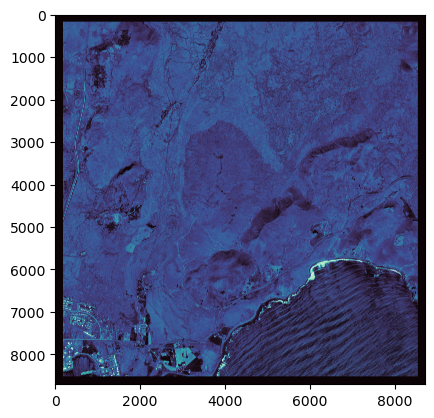

<Axes: >

In [4]:
show(ds_rasterio.read(1), cmap="mako")

In rasterio, we can use the object [`Window`](https://rasterio.readthedocs.io/en/stable/api/rasterio.windows.html) to create one.

In the following case, we will create a subset of our image with `1500 rows x 1500 columns`. When initializing our `Window`, we will specify its size (width and height) and the position of the top-left pixel where to start creating it.

In [6]:
window = Window(col_off=1500, row_off=1500, width=1500, height=1500) #1500 x 1500

We will focus on the first band for our example.

We create an object `w` that will represent a subset of our image. As a parameter, we specify `window=window` to use the window object previously created as extent.

In [6]:
b1 = ds_rasterio.read(1)

w = ds_rasterio.read(1, window=window)

Let's compare the full raster with the subset image created with the Window:

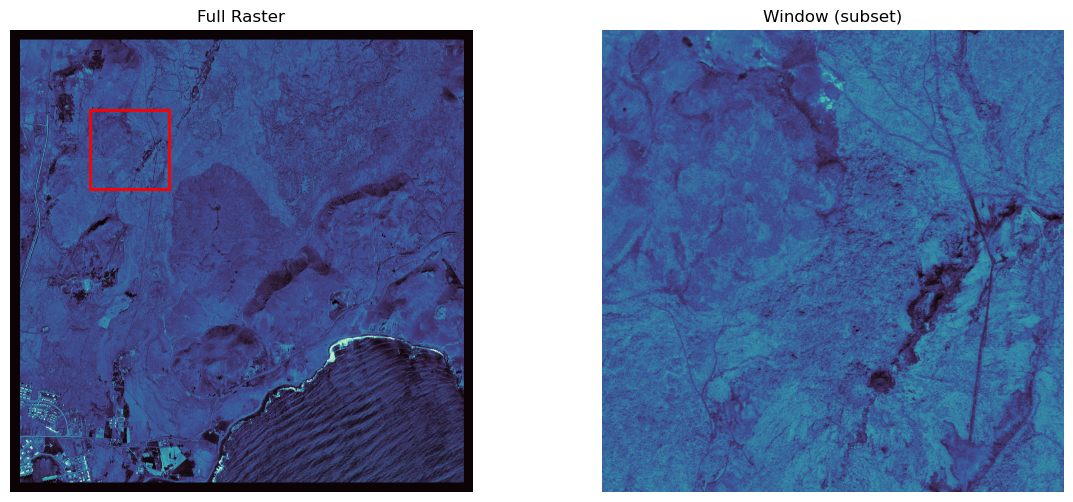

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#full raster
axes[0].imshow(b1, cmap="mako")
axes[0].set_title("Full Raster")
axes[0].axis("off")

#rectangle
rect = patches.Rectangle(
    (window.col_off, window.row_off),
    window.width,
    window.height,
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)

#window raster
axes[1].imshow(w, cmap="mako")
axes[1].set_title("Window (subset)")
axes[1].axis("off")

plt.show()

### • *rioxarray*

In [4]:
ds_rioxarray = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

With rioxarray, we can use [`.isel_window()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.rioxarray.XRasterBase.isel_window) to create a subset of our image. 

We will pass our `rasterio` `Window` object as an argument (as it is requested in the documentation of the function) to specify the extents of the new raster :

In [7]:
window

Window(col_off=1500, row_off=1500, width=1500, height=1500)

In [8]:
rioxarray_subset = ds_rioxarray.rio.isel_window(window)

And if we plot the result :

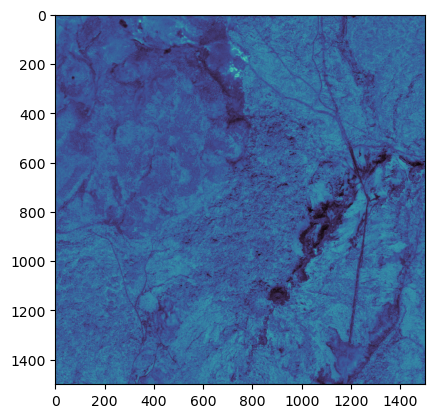

<Axes: >

In [9]:
show(rioxarray_subset.sel(band=1), cmap="mako")

- ### *geoutils*

In geoutils, this feature has an [opened issue](https://github.com/GlacioHack/geoutils/issues/583).

Creating a window through geoutils uses a different mechanism from other libraries. The right way for that is to open the data object and then to use [`.crop()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.crop.html#geoutils.Raster.crop) or [`.icrop()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.icrop.html#geoutils.Raster.icrop).

This method is more detailed in the [`mask_and_crop`](https://github.com/sertit/open_source_rasters_comparison/blob/main/notebooks/04_mask_and_crop.ipynb) notebook.

## **Decimation**

Decimation is used to reduce the image resolution of a raster by skipping a certain amount of pixels in rows, columns or both, or by calculating the average of the surrounding pixels. The method applied depends on the chosen resampling method. By default, rasterio seems to use [`nearest`](https://rasterio.readthedocs.io/en/stable/api/rasterio.enums.html#rasterio.enums.Resampling.nearest), which will take the value of the nearest pixel and "skip" others. `average` will compute the weighted average of all non-nodata contributing pixels, and some other methods will do an interpolation (`bilinear`, `cubic`, `cubic_spline`, `lanczos`, ...).

Decimation is particularly useful to speed up the display or analyze large raster files.

### • *rasterio*

In the following case, we will reduce the size by half (height and width). 

Our raster's size is `8705 x 8705`, so we want to reshape it as `4352 x 4352`. 

We can do so by using the [`.read()`](https://rasterio.readthedocs.io/en/stable/api/rasterio._io.html#rasterio._io.DatasetReaderBase.read) function, but we will use the *out_shape* argument to select the extent we want to keep, which is quite straight-forward :

In [7]:
decimated_b1 = ds_rasterio.read(1, out_shape=(4352, 4352))

We can now plot the decimated raster :

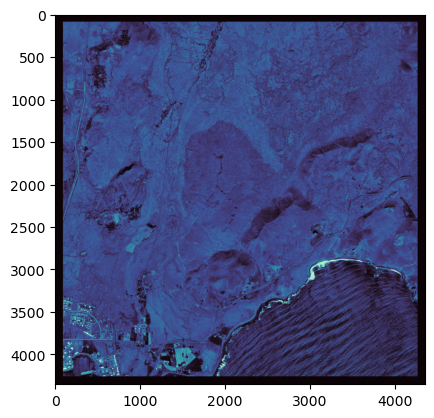

<Axes: >

In [8]:
show(decimated_b1, cmap="mako")

We can validate the new shape with `.shape` as follows :

In [9]:
decimated_b1.shape

(4352, 4352)

### • *rioxarray*

There is no trivial method to decimate an image through `xarray` and especially `rioxarray`, unlike `rasterio`.

To do so, we first have to `reproject` it and then use a `resampling` algorithm, as shown below:

In [10]:
da = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

Here we specify our new wanted resolution. We will multiply it by 2, so the final size of our raster will be divided by 2:

In [11]:
new_res = (
    da.rio.resolution()[0] * 2,
    da.rio.resolution()[1] * 2
)

Finally, we will use [`.reproject()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject) and we specify the original CRS, the new resolution and the resampling method (`average` here):

In [12]:
da_decimated = da.rio.reproject(
    da.rio.crs,
    resolution=new_res,
    resampling=Resampling.average
)

We can finally plot the new map:

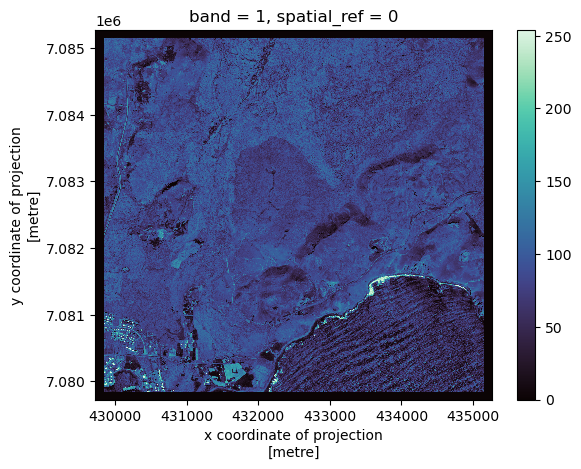

In [13]:
da_decimated.sel(band=1).plot(cmap="mako")

Once again we can check the shape of the new image :

In [17]:
print(f"Size : {da_decimated.rio.width} x {da_decimated.rio.height}")

Size : 4353 x 4353
